In [162]:
%load_ext autoreload
%autoreload 2

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [163]:
from gecco import GeCCoConfig, GeCCoPipeline
from gecco.preprocess import DataPreprocessor
from gecco.tree import ModuleTreeBuilder, ModuleNode
from gecco.visualize import plot_module_tree, plot_node_genes

In [3]:
adata = sc.read_h5ad('../datasets/BMMC_ds.h5ad')


In [164]:
cfg = GeCCoConfig()
cfg.pp_enabled = True
preprocessor = DataPreprocessor(cfg)
pre = preprocessor.run(adata)

In [192]:
pipeline = GeCCoPipeline(cfg)
result = pipeline.run(adata, pre)

图已保存至: ../outputs/module_tree.png


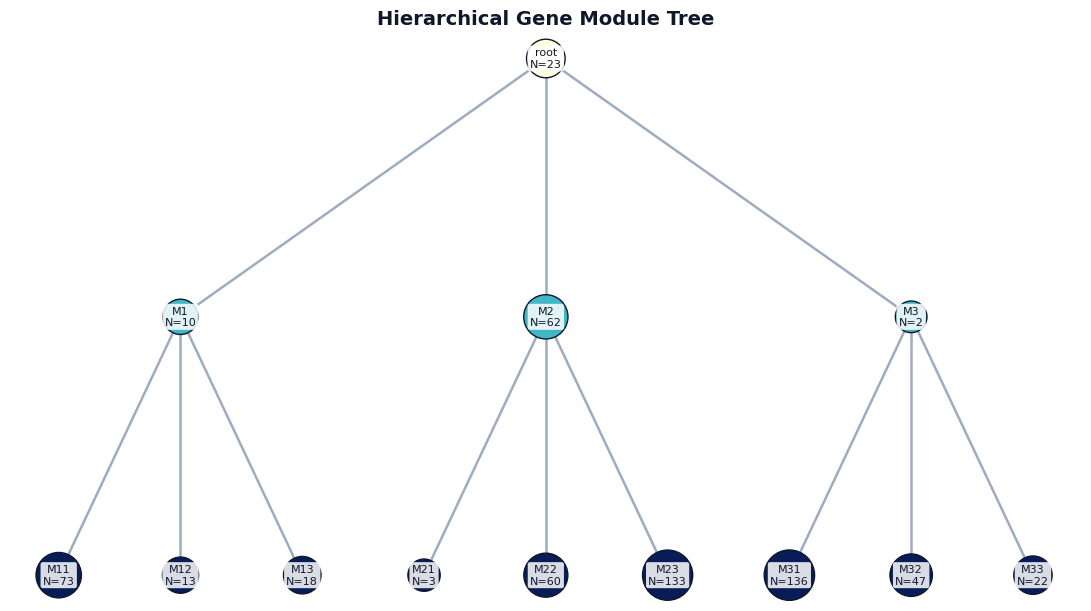

In [193]:
plot_module_tree(result.tree_root, "../outputs/module_tree.png")

图已保存至: ../outputs/node_genes.png


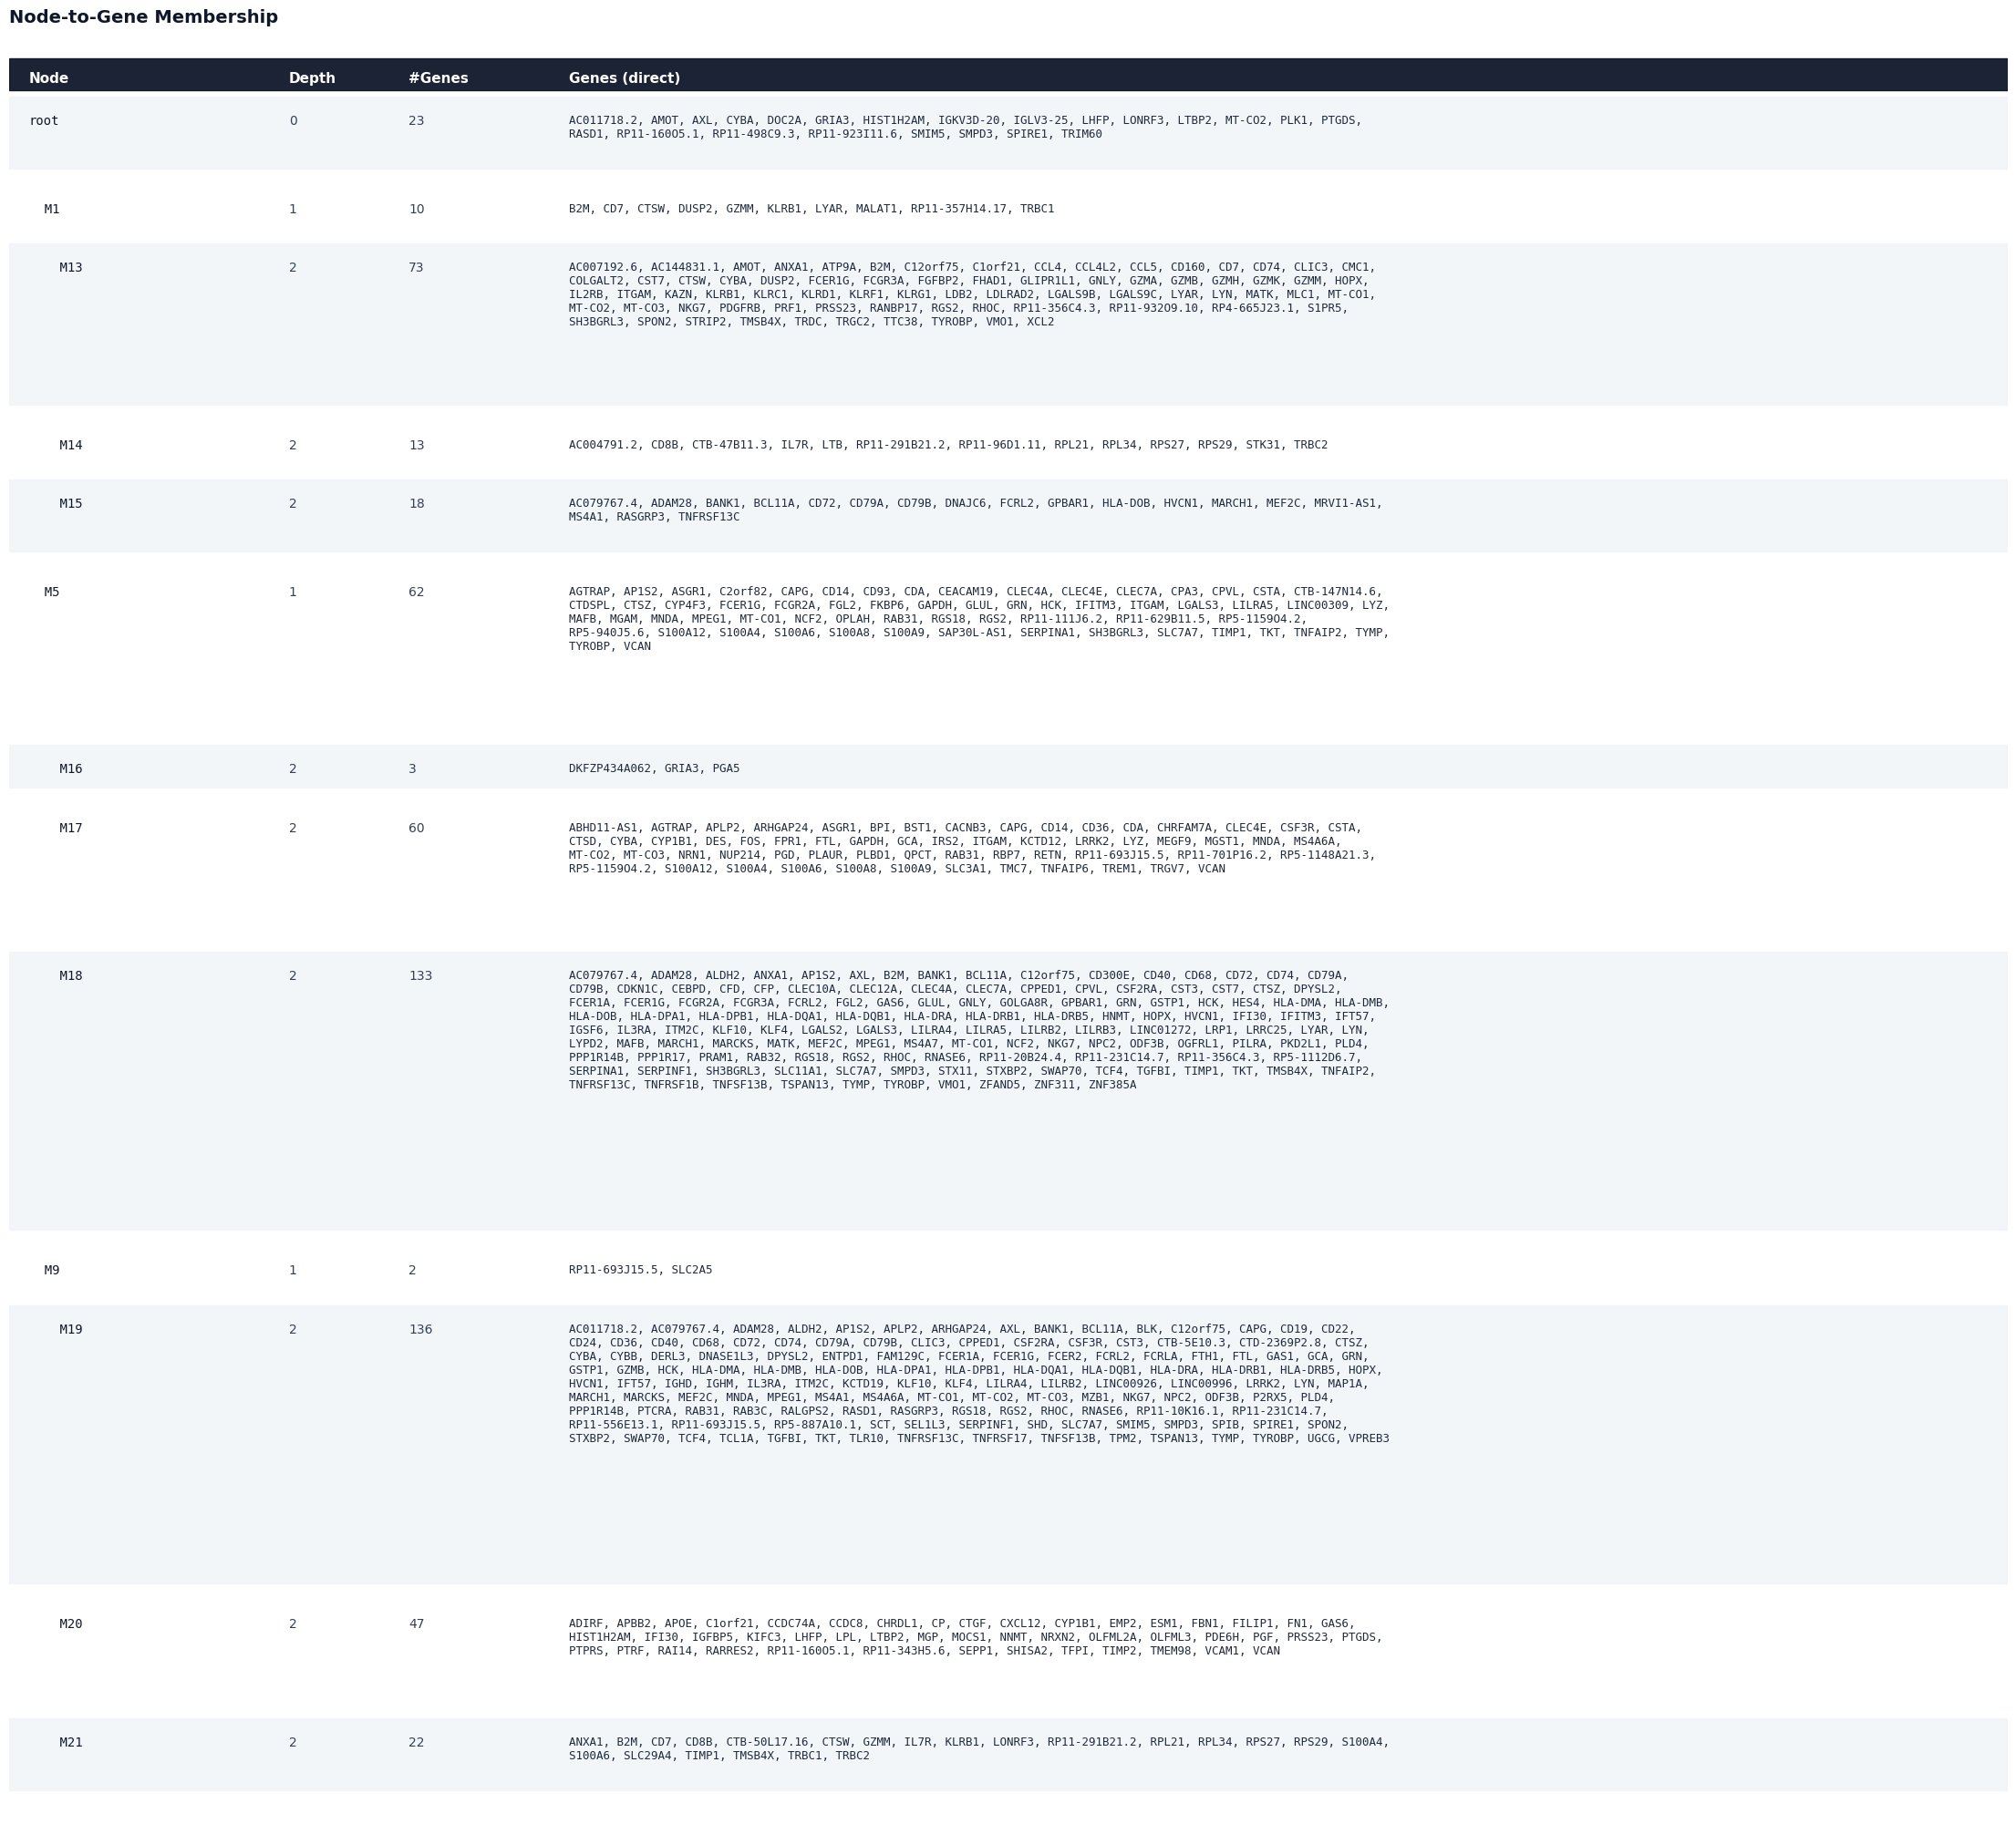

In [194]:
plot_node_genes(result.tree_root,"../outputs/node_genes.png")

In [168]:
from gecco.utils import add_tree_labels_to_var
add_tree_labels_to_var(adata, result.tree_root)

In [169]:
from gecco.utils import add_depth_labels_to_obs
add_depth_labels_to_obs(adata, result)

In [170]:
depth1_values = adata.obs['depth1'].unique()
vals = sorted(depth1_values)

adata1 = adata[adata.obs['depth1'] == vals[0]].copy()
adata2 = adata[adata.obs['depth1'] == vals[1]].copy()
adata3 = adata[adata.obs['depth1'] == vals[2]].copy()

In [171]:
preprocessor = DataPreprocessor(cfg)
pre1 = preprocessor.run(adata1)
pre2 = preprocessor.run(adata2)
pre3 = preprocessor.run(adata3)

In [182]:
cfg.pp_n_depth2 = 0 
pipeline1 = GeCCoPipeline(cfg)
result1 = pipeline1.run(adata1, pre1)

pipeline2 = GeCCoPipeline(cfg)
result2 = pipeline2.run(adata2, pre2)

pipeline3 = GeCCoPipeline(cfg)
result3 = pipeline3.run(adata3, pre3)


In [183]:
add_depth_labels_to_obs(adata1, result1)
add_depth_labels_to_obs(adata2, result2)
add_depth_labels_to_obs(adata3, result3)

In [184]:
d1 = adata1.obs['depth1'].astype(str).rename('depth2 locally').add_prefix_to_values = None

local1 = adata1.obs[['depth1']].copy()
local1['depth2 locally'] = vals[0] + '_' + local1['depth1'].astype(str)

local2 = adata2.obs[['depth1']].copy()
local2['depth2 locally'] = vals[1] + '_' + local2['depth1'].astype(str)

local3 = adata3.obs[['depth1']].copy()
local3['depth2 locally'] = vals[2] + '_' + local3['depth1'].astype(str)

combined = pd.concat([
    local1['depth2 locally'],
    local2['depth2 locally'],
    local3['depth2 locally'],
])

adata.obs['depth2 locally'] = combined.reindex(adata.obs.index)

print(adata.obs['depth2 locally'].value_counts())
print(f"Total unique labels: {adata.obs['depth2 locally'].nunique()}")

depth2 locally
M1_M5    1714
M1_M1     710
M9_M1     542
M5_M5     524
M5_M9     482
M5_M1     346
M1_M9     326
M9_M5     221
M9_M9     135
Name: count, dtype: int64
Total unique labels: 9


In [185]:
from _utils.sankey import plot_anndata_sankey
plot_anndata_sankey(
    adata,
    sort_label='depth2',
    left_label='depth2',
    right_label='depth2 locally',
)